In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
file_folder = 'locomotion/'

frequencies = [10, 40]
midfix_range = range(1, 6)
suffix = '.csv'
filenames = []
dfs = []

for frequency in frequencies:
    for midfix in midfix_range:
        filename = f"{file_folder}s{frequency}hz{midfix}-{midfix}{suffix}"
        dfs.append(pd.read_csv(filename, header=1))
        dfs[-1]['name'] = filename
        dfs[-1]['frequency'] = frequency
        dfs[-1].columns = ['time', 'x', 'y', 'theta', 'omega', 'alpha','name', 'freq']

In [3]:
# # polar plot of theta vs omega
# all_thetas = []
# all_omegas = []
# all_alphas = []
# all_theta_field = []

# plt.figure(figsize=(5, 5))
# for df in dfs:
#     dt = df['time'].values[1] - df['time'].values[0]
#     thetas = df['theta'].values[2:-2] / 180 * np.pi
#     omegas = df['omega'].values[2:-2] / 180 * np.pi
#     alphas = df['alpha'].values[2:-2] / 180 * np.pi
#     all_thetas.extend(thetas)
#     all_omegas.extend(omegas)
#     all_alphas.extend(alphas)
    
#     w_field = df['freq'].values[0]
#     w_field = 2 * np.pi * w_field
#     ts = np.arange(0, len(thetas))*dt
#     theta_field = w_field * ts
#     theta_field = theta_field % (2 * np.pi)
#     all_theta_field.extend(theta_field)
#     plt.polar(thetas, omegas, '-o', markersize=1, linewidth=0.5)
# plt.show()


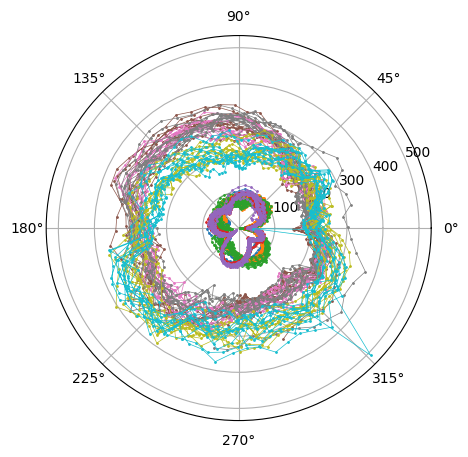

In [4]:
# polar plot of theta vs omega
all_thetas = []
all_omegas = []
all_alphas = []
all_theta_field = []

plt.figure(figsize=(5, 5))
for df in dfs:
    dt = df['time'].values[1] - df['time'].values[0]
    
    # Smooth theta first (using a rolling mean or similar, here using a simple convolution for example)
    # Adjust window size as needed.
    raw_thetas = df['theta'].values / 180 * np.pi
    window_size = 7
    kernel = np.ones(window_size) / window_size
    smoothed_thetas = np.convolve(raw_thetas, kernel, mode='valid')

    # Calculate omega from smoothed theta to ensure consistency
    # omega = d(theta) / dt
    smoothed_omegas = np.diff(smoothed_thetas) / dt
    
    # Adjust lengths to match due to diff and convolve
    # np.diff reduces length by 1. We need to align arrays.
    thetas = smoothed_thetas[:-1] # Align with omega
    omegas = smoothed_omegas
    
    # Since we don't have a consistent alpha calculation instruction relative to the new smoothing, 
    # we will just grab the raw alphas matching the length or re-derive if needed. 
    # Assuming raw slice for visualization purposes based on original code structure.
    # Original code sliced [2:-2]. Let's try to match the center of the data.
    start_idx = (len(df['alpha']) - len(thetas)) // 2
    alphas = df['alpha'].values[start_idx : start_idx + len(thetas)] / 180 * np.pi

    all_thetas.extend(thetas)
    all_omegas.extend(omegas)
    all_alphas.extend(alphas)
    
    w_field = df['freq'].values[0]
    w_field = 2 * np.pi * w_field
    ts = np.arange(0, len(thetas))*dt
    theta_field = w_field * ts
    theta_field = theta_field % (2 * np.pi)
    all_theta_field.extend(theta_field)
    plt.polar(thetas, omegas, '-o', markersize=1, linewidth=0.5)
plt.show()

In [5]:
# Dynamics-related quantities and F_hat computation
m = 1.4e-5
d = 2e-3
J = 1/6 * m * d**2
B = 1e-6

all_alphas = np.array(all_alphas)
all_thetas = np.array(all_thetas)
all_omegas = np.array(all_omegas)
all_theta_field = np.array(all_theta_field)

all_ts = np.arange(0, len(all_thetas))*dt

F_hat = B*np.sin(all_theta_field - all_thetas) - J*all_alphas

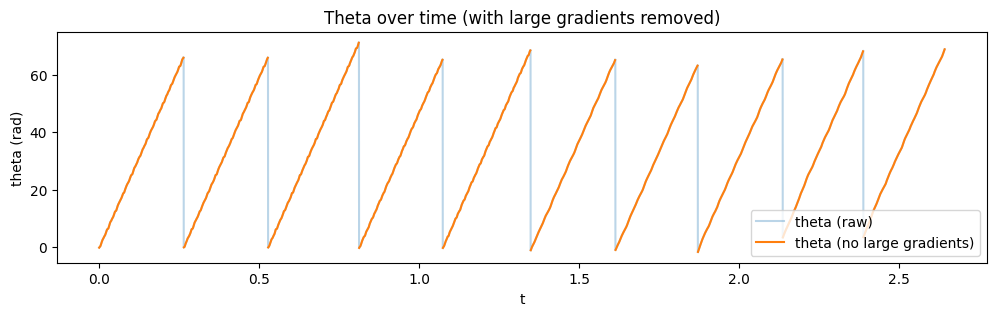

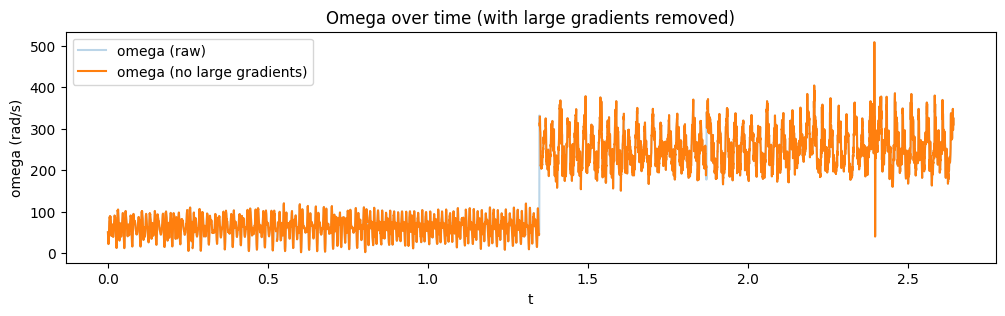

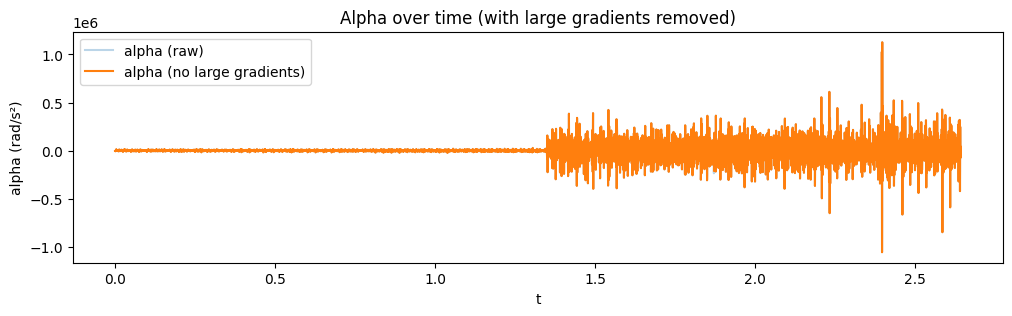

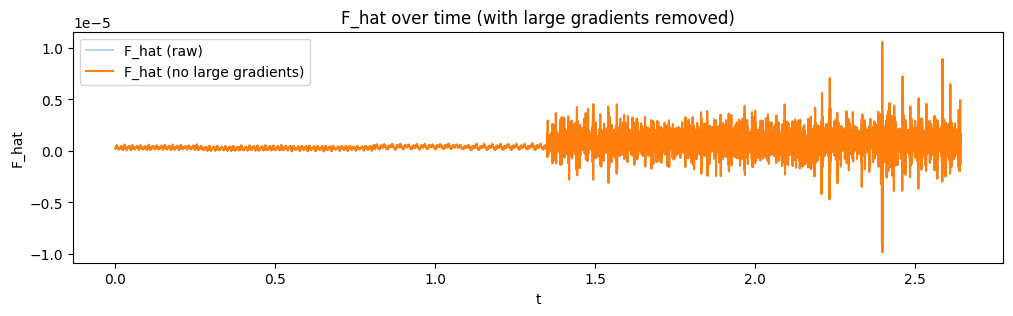

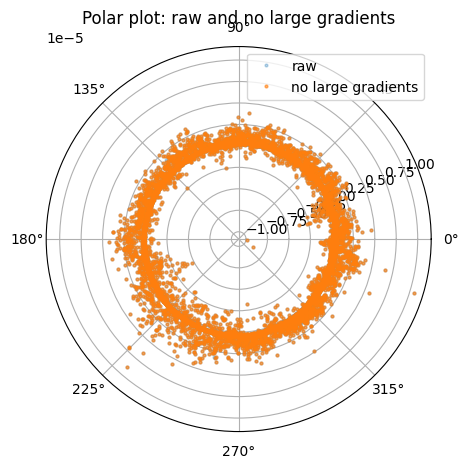

In [6]:
# Remove points with large gradients in theta (i.e., likely trajectory boundaries)
def get_discontinuity_mask(data, threshold=4.0):
    """
    Returns a mask that is False at indices where the gradient
    exceeds a threshold times the median absolute gradient.
    """
    grad = np.abs(np.gradient(data))
    med_grad = np.median(grad)
    thresh_val = threshold * med_grad
    mask = grad < thresh_val
    # Also mask the point after a discontinuity
    mask[:-1] = mask[:-1] & mask[1:]
    return mask

# Mask points with high theta gradients
mask = get_discontinuity_mask(all_thetas, threshold=4.0)

# Remove (set to NaN) the large gradient points from the signals
thetas_clean = np.copy(all_thetas)
omegas_clean = np.copy(all_omegas)
alphas_clean = np.copy(all_alphas)
F_hat_clean = np.copy(F_hat)

thetas_clean[~mask] = np.nan
omegas_clean[~mask] = np.nan
alphas_clean[~mask] = np.nan
F_hat_clean[~mask] = np.nan

plt.figure(figsize=(12, 3))
plt.plot(all_ts, all_thetas, label='theta (raw)', alpha=0.3)
plt.plot(all_ts, thetas_clean, label='theta (no large gradients)')
plt.legend()
plt.title('Theta over time (with large gradients removed)')
plt.xlabel('t')
plt.ylabel('theta (rad)')
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(all_ts, all_omegas, label='omega (raw)', alpha=0.3)
plt.plot(all_ts, omegas_clean, label='omega (no large gradients)')
plt.legend()
plt.title('Omega over time (with large gradients removed)')
plt.xlabel('t')
plt.ylabel('omega (rad/s)')
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(all_ts, all_alphas, label='alpha (raw)', alpha=0.3)
plt.plot(all_ts, alphas_clean, label='alpha (no large gradients)')
plt.legend()
plt.title('Alpha over time (with large gradients removed)')
plt.xlabel('t')
plt.ylabel('alpha (rad/s²)')
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(all_ts, F_hat, label='F_hat (raw)', alpha=0.3)
plt.plot(all_ts, F_hat_clean, label='F_hat (no large gradients)')
plt.legend()
plt.title('F_hat over time (with large gradients removed)')
plt.xlabel('t')
plt.ylabel('F_hat')
plt.show()

plt.figure(figsize=(5, 5))
plt.polar(all_thetas, F_hat, 'o', markersize=2, alpha=0.3, label='raw')
plt.polar(thetas_clean[mask], F_hat_clean[mask], 'o', markersize=2, alpha=0.6, label='no large gradients')
plt.title('Polar plot: raw and no large gradients')
plt.legend(["raw", "no large gradients"])
plt.show()


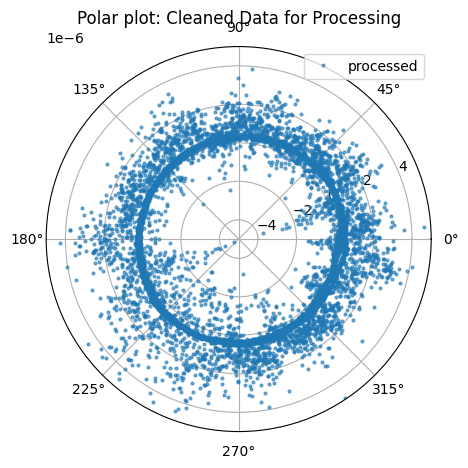

In [7]:
# Save cleaned thetas, omegas, F_hat, alpha, and theta_field for downstream processing, removing NaNs
valid_mask = (~np.isnan(thetas_clean)) & (~np.isnan(omegas_clean)) & (~np.isnan(F_hat_clean))
thetas_clean_for_processing = thetas_clean[valid_mask]
omegas_clean_for_processing = omegas_clean[valid_mask]
F_hat_clean_for_processing = F_hat_clean[valid_mask]

# Also save alpha and theta_field for alternative system identification approaches
alphas_clean_for_processing = alphas_clean[valid_mask]
theta_field_clean_for_processing = all_theta_field[valid_mask]

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, polar=True)
ax.plot(thetas_clean_for_processing, F_hat_clean_for_processing, 'o', markersize=2, alpha=0.6, label='processed')
ax.set_title('Polar plot: Cleaned Data for Processing')
ax.set_rmin(-0.5e-5)
ax.set_rmax(0.5e-5)
ax.legend(["processed"])
plt.show()


In [8]:
import plotly.graph_objs as go
import plotly.io as pio

theta = thetas_clean
r = omegas_clean
z = F_hat_clean

x = r * np.cos(theta)
y = r * np.sin(theta)

# Determine the max absolute value for x and y for equal aspect
max_range = max(np.abs(x).max(), np.abs(y).max())

scatter = go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=3,
        color=z,
        colorscale='Viridis',
        colorbar=dict(title='F_hat_clean')
    )
)

layout = go.Layout(
    title='3D Scatter (polar): θ, ω, F_hat (cleaned)',
    scene=dict(
        xaxis_title='ω cos(θ)',
        yaxis_title='ω sin(θ)',
        zaxis_title='F_hat (cleaned)',
        # xaxis=dict(range=[-max_range, max_range]),
        # yaxis=dict(range=[-max_range, max_range]),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1)
    ),
    height=600,
    width=800
)

fig = go.Figure(data=[scatter], layout=layout)
fig.show()


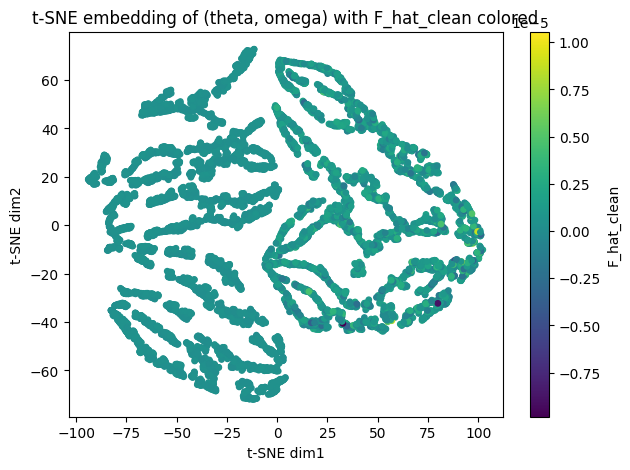

/home/sman/miniconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

/home/sman/miniconda3/envs/py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



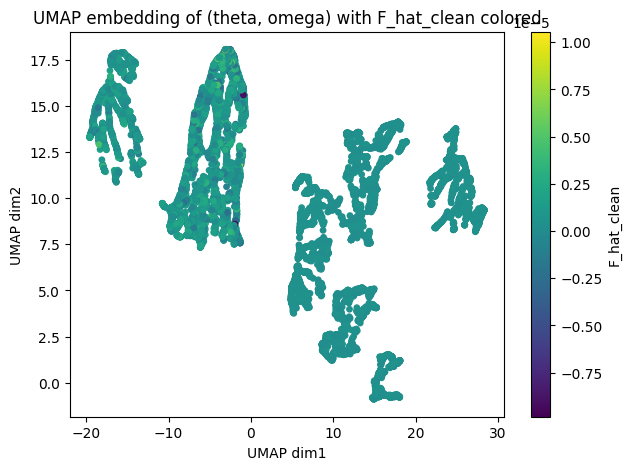

In [9]:
# We'll use t-SNE and UMAP (if available) to visualize theta, omega -> F_hat mapping

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

X = np.vstack([thetas_clean_for_processing, omegas_clean_for_processing]).T
y = F_hat_clean_for_processing

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_embedded_tsne = tsne.fit_transform(X)

plt.figure(figsize=(7,5))
sc = plt.scatter(X_embedded_tsne[:,0], X_embedded_tsne[:,1], c=y, cmap='viridis', s=15)
plt.colorbar(sc, label="F_hat_clean")
plt.title("t-SNE embedding of (theta, omega) with F_hat_clean colored")
plt.xlabel("t-SNE dim1")
plt.ylabel("t-SNE dim2")
plt.show()

# Try UMAP if available (optional)
try:
    import umap
    reducer = umap.UMAP(random_state=42)
    X_embedded_umap = reducer.fit_transform(X)
    plt.figure(figsize=(7,5))
    sc = plt.scatter(X_embedded_umap[:,0], X_embedded_umap[:,1], c=y, cmap='viridis', s=15)
    plt.colorbar(sc, label="F_hat_clean")
    plt.title("UMAP embedding of (theta, omega) with F_hat_clean colored")
    plt.xlabel("UMAP dim1")
    plt.ylabel("UMAP dim2")
    plt.show()
except ImportError:
    print("UMAP not installed; skipping UMAP visualization.")



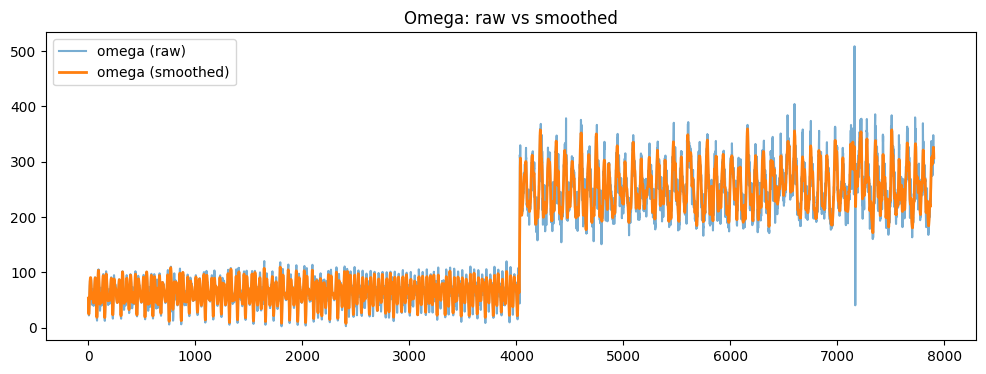

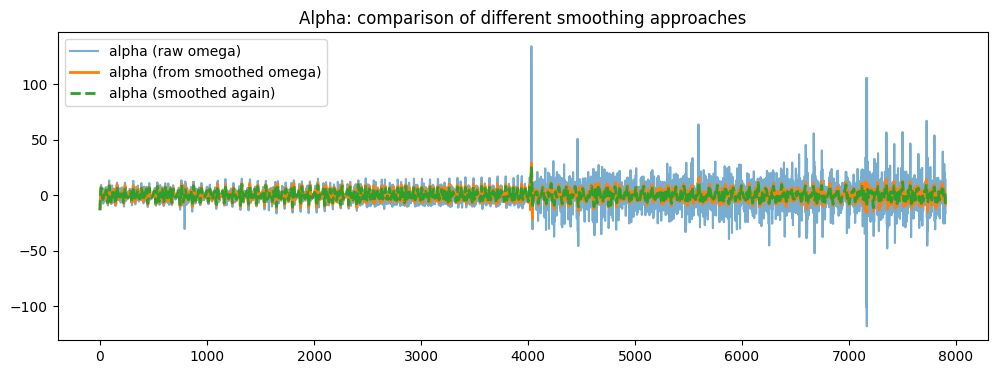

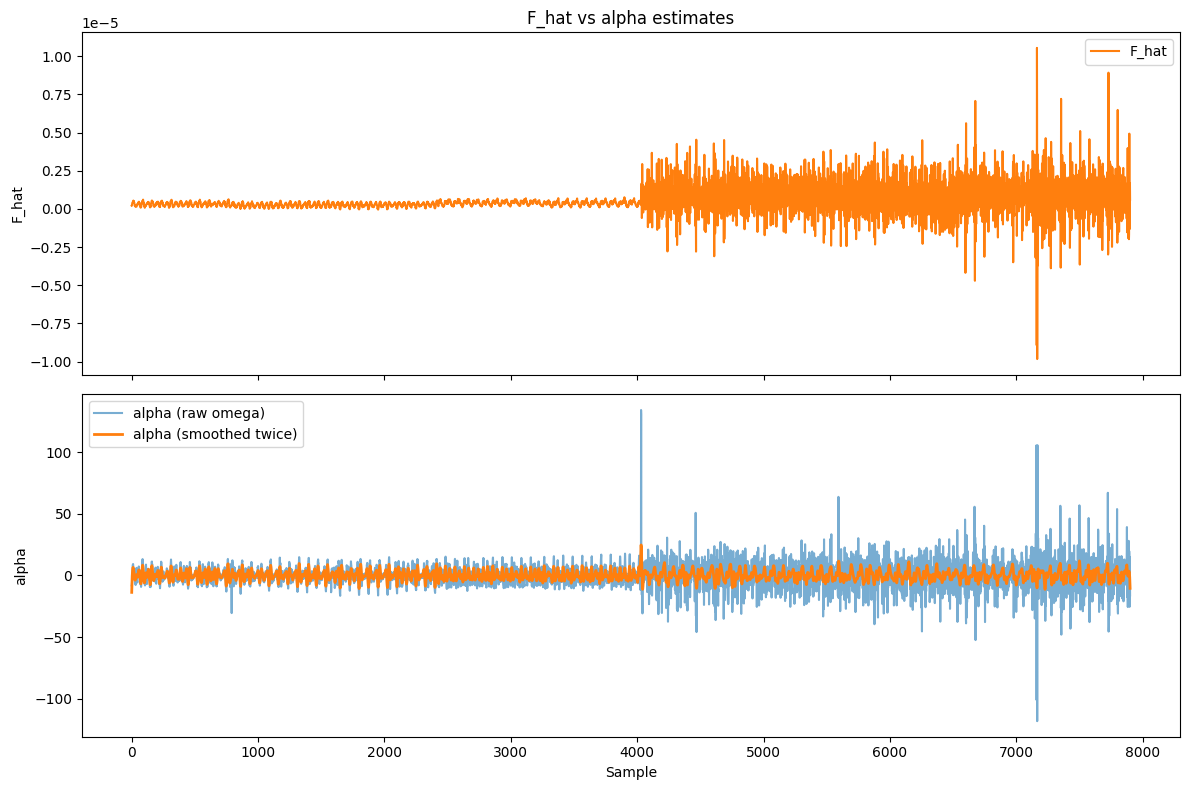

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Smooth omegas over time
window_length = 21 if len(omegas_clean_for_processing) > 21 else (len(omegas_clean_for_processing) // 2) * 2 + 1
polyorder = 3 if window_length > 3 else 2

omegas_smooth = savgol_filter(omegas_clean_for_processing, window_length=window_length, polyorder=polyorder)

# Estimate dt: assume uniform sampling
if len(thetas_clean_for_processing) > 1:
    dt = np.median(np.diff(thetas_clean_for_processing) * 0 + 1)  # Fallback: set dt=1 if only have states, not timestamps
    # But check if time_stamps_clean_for_processing exists to get dt
    if 'time_stamps_clean_for_processing' in locals():
        dt = np.median(np.diff(time_stamps_clean_for_processing))
    elif 'times_clean_for_processing' in locals():
        dt = np.median(np.diff(times_clean_for_processing))
    else:
        dt = 1.0
else:
    dt = 1.0

# Differentiate and smooth again to get alphas
alpha_est = np.gradient(omegas_clean_for_processing, dt)
alpha_est_smooth = np.gradient(omegas_smooth, dt)
alpha_est_smooth2 = savgol_filter(alpha_est_smooth, window_length=window_length, polyorder=polyorder)

# Plot omegas and smoothed omegas
plt.figure(figsize=(12,4))
plt.plot(omegas_clean_for_processing, label="omega (raw)", alpha=0.6)
plt.plot(omegas_smooth, label="omega (smoothed)", linewidth=2)
plt.legend()
plt.title("Omega: raw vs smoothed")
plt.show()

# Plot raw alpha, alpha from smoothed omega, and twice-smoothed alpha
plt.figure(figsize=(12,4))
plt.plot(alpha_est, label="alpha (raw omega)", alpha=0.6)
plt.plot(alpha_est_smooth, label="alpha (from smoothed omega)", linewidth=2)
plt.plot(alpha_est_smooth2, label="alpha (smoothed again)", linewidth=2, linestyle='--')
plt.legend()
plt.title("Alpha: comparison of different smoothing approaches")
plt.show()

# Compare F_hat vs alphas
fig, axs = plt.subplots(2, 1, figsize=(12,8), sharex=True)

axs[0].plot(F_hat_clean_for_processing, label="F_hat", color="tab:orange")
axs[0].set_ylabel("F_hat")
axs[0].legend()
axs[0].set_title("F_hat vs alpha estimates")

axs[1].plot(alpha_est, label="alpha (raw omega)", alpha=0.6)
axs[1].plot(alpha_est_smooth2, label="alpha (smoothed twice)", linewidth=2)
axs[1].set_ylabel("alpha")
axs[1].set_xlabel("Sample")
axs[1].legend()

plt.tight_layout()
plt.show()


In [13]:
import plotly.graph_objs as go
import numpy as np

# Compute new smooth F_hat using the clean and smoothed variables
m = 1.4e-5
d = 2e-3
J = 1/6 * m * d**2
B = 1e-6

F_hat_new_smooth = B * np.sin(theta_field_clean_for_processing - thetas_clean_for_processing) - J * alpha_est_smooth2

# 3D scatter plot (polar for theta and omega)
def plot_polar_3d_scatter(color_variable='F_hat_new'):
    theta = thetas_clean_for_processing
    omega = omegas_clean_for_processing
    if color_variable == 'F_hat_new':
        color_vals = F_hat_new_smooth
        c_label = "F_hat (new smoothed)"
    else:
        color_vals = F_hat_clean_for_processing
        c_label = "F_hat (original clean)"

    # Convert polar theta/omega to cartesian for 3D scatter, but keep polar as two axes
    # If you like you might plot radius=omega, angle=theta, z=color_variable
    theta_deg = np.rad2deg(theta)

    # 3D polar plot: θ (angle), ω (radius), F_hat (z/color)
    fig = go.Figure(data=[go.Scatter3d(
        x=np.cos(theta) * omega,
        y=np.sin(theta) * omega,
        z=color_vals,
        mode='markers',
        marker=dict(
            size=2,
            color=color_vals,
            colorscale='Viridis',
            colorbar=dict(title=c_label),
            showscale=True,
            opacity=0.8,
        ),
        text=[f"{c_label}: {val:.3g}" for val in color_vals],
        name=c_label
    )])

    fig.update_layout(
        scene = dict(
            xaxis_title='ω × cos(θ)',
            yaxis_title='ω × sin(θ)',
            zaxis_title=c_label,
            xaxis=dict(backgroundcolor="white", gridcolor="lightgray"),
            yaxis=dict(backgroundcolor="white", gridcolor="lightgray"),
            zaxis=dict(backgroundcolor="white", gridcolor="lightgray"),
        ),
        title=f"3D Polar Scatter: θ (angle), ω (radius), {c_label} (z)",
        width=700, height=600,
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()

# To change color-mapping, call: plot_polar_3d_scatter(color_variable='F_hat_clean') or 'F_hat_new'
plot_polar_3d_scatter(color_variable='F_hat_new')  # Example usage


In [14]:
# Save the processed data for the modeling notebook
# Including alpha and theta_field for alternative system identification approaches
np.savez('processed_data.npz',
         thetas=thetas_clean_for_processing,
         omegas=omegas_clean_for_processing,
         F_hat=F_hat_clean_for_processing,
         alpha=alphas_clean_for_processing,
         theta_field=theta_field_clean_for_processing)

# Also save the smoothed data for further analysis or modeling
np.savez('processed_data_smooth.npz',
         thetas=thetas_clean_for_processing,
         omegas=omegas_clean_for_processing,
         F_hat=F_hat_new_smooth,
         alpha=alphas_clean_for_processing,
         theta_field=theta_field_clean_for_processing)
